In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from scipy.stats import pearsonr

# 1. 获取数据
tickers = ['KO', 'PEP']
# 为了复现书中的逻辑，我们建议拉取一段较长的时间，比如 2020 年至今
data = yf.download(tickers, start="2023-01-01", end="2026-01-01")['Close'].dropna()

# 2. 协整检验 (CADF Test)
# 对应书中：检测价格水平是否具有长期平稳关系
t_stat, p_val_coint, crit_values = coint(data['KO'], data['PEP'])

print("--- 协整检验 (Cointegration) ---")
print(f"CADF t-statistic: {t_stat:.4f}")
print(f"10% Critical Value: {crit_values[2]:.4f}")
print(f"P-value: {p_val_coint:.4f}")
print("结论: " + ("显著协整" if p_val_coint < 0.1 else "不具有显著协整关系"))
print("-" * 30)

# 3. 相关性检验 (Correlation)
# 对应书中：检测日收益率 (Daily Returns) 的相关性
daily_returns = data.pct_change().dropna()

# 计算相关系数矩阵 R 和显著性水平 P
# np.corrcoef 只返回相关系数，scipy.stats.pearsonr 可以同时返回 R 和 P
r_val, p_val_corr = pearsonr(daily_returns['KO'], daily_returns['PEP'])

print("--- 相关性检验 (Correlation) ---")
print(f"相关系数 R: {r_val:.4f}")
print(f"P-value (显著性): {p_val_corr:.4g}") # 书中 P=0 说明极度显著
print("结论: " + ("显著相关" if p_val_corr < 0.05 else "不显著相关"))

/tmp/ipykernel_604348/358739770.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2023-01-01", end="2026-01-01")['Close'].dropna()
[*********************100%***********************]  2 of 2 completed

--- 协整检验 (Cointegration) ---
CADF t-statistic: -2.3240
10% Critical Value: -3.0501
P-value: 0.3616
结论: 不具有显著协整关系
------------------------------
--- 相关性检验 (Correlation) ---
相关系数 R: 0.6275
P-value (显著性): 1.884e-83
结论: 显著相关


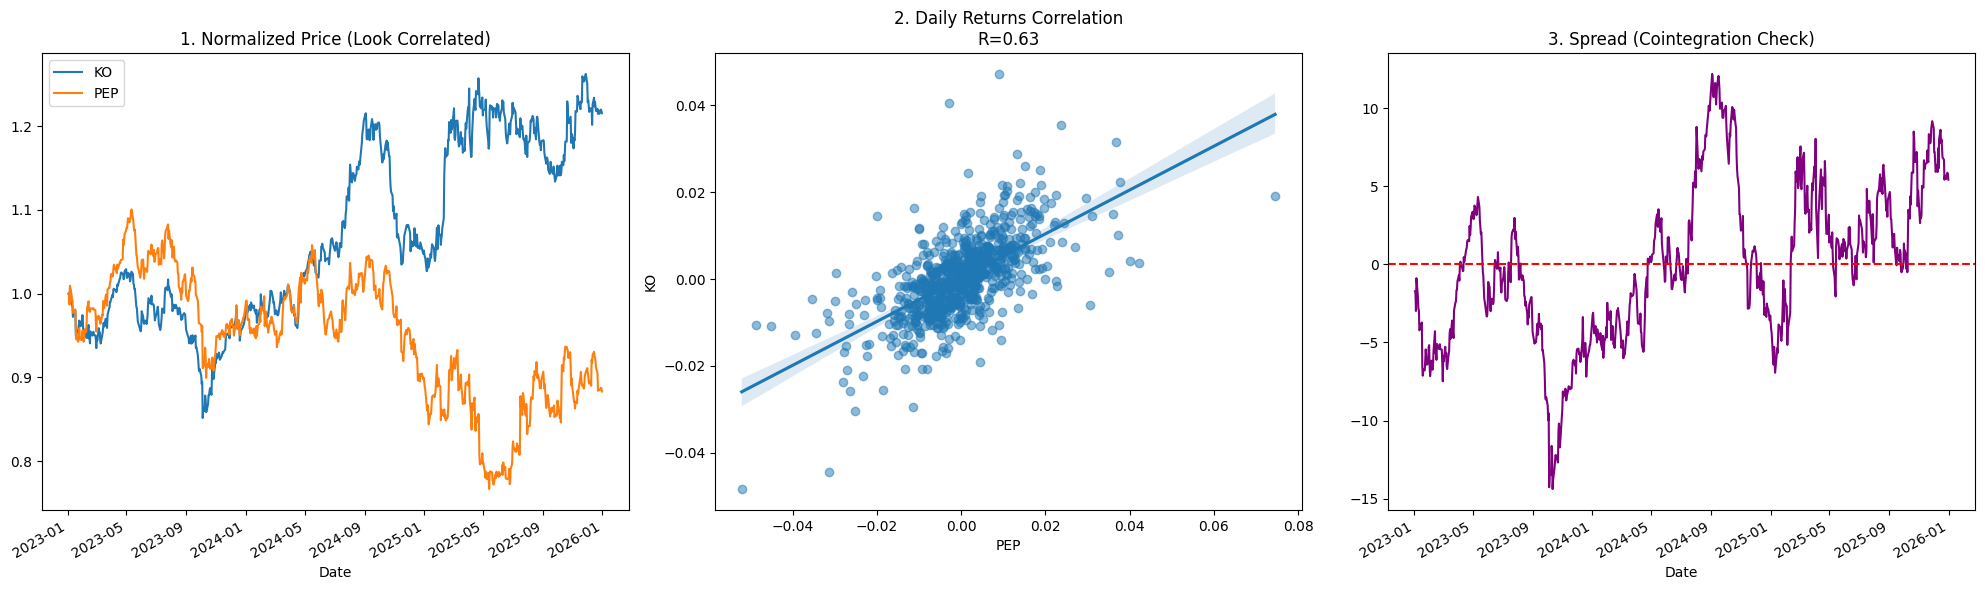

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# OLS回归计算对冲比例
model = sm.OLS(data['KO'], sm.add_constant(data['PEP'])).fit()
spread = model.resid

# --- 开始绘图 ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 图1：价格走势 (看上去高度相关)
df_norm = data / data.iloc[0] # 归一化处理以便对比
df_norm.plot(ax=axes[0])
axes[0].set_title("1. Normalized Price (Look Correlated)")
axes[0].legend()

# 图2：收益率散点图 (验证相关性 Correlation)
sns.regplot(x=daily_returns['PEP'], y=daily_returns['KO'], ax=axes[1], scatter_kws={'alpha':0.5})
axes[1].set_title(f"2. Daily Returns Correlation\nR={daily_returns.corr().iloc[0,1]:.2f}")

# 图3：价差序列 (验证协整性 Cointegration)
spread.plot(ax=axes[2], color='purple')
axes[2].axhline(spread.mean(), color='red', linestyle='--')
axes[2].set_title("3. Spread (Cointegration Check)")

plt.tight_layout()
plt.show()